In [1]:
#import the correct packages
#going to try to use the ordinal model here!

import sys #import the local edited python file 
sys.path.insert(0, '/Users/elihallowell/Documents/BU2024/Thesis/sustainrepo/pySuStaIn1')
import pySuStaIn
from pySuStaIn import OrdinalSustain
import numpy as np
import os
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import sklearn.model_selection
import pandas as pd
import pylab
import sys #import the local edited python file 
sys.path.insert(0, '/Users/elihallowell/Documents/BU2024/Thesis/sustainrepo/pySuStaIn1')
import pySuStaIn
print(pySuStaIn.__file__)


/Users/elihallowell/Documents/BU2024/Thesis/sustainrepo/pySuStaIn1/pySuStaIn/__init__.py


In [2]:
#simulate ordinal data: 100 subjects × 3 regions, ratings 0–3 from no disease to severe
# could be ratings from a neuropathologist
np.random.seed(0)
n_subjects = 100
X = np.random.randint(0, 4, size=(n_subjects, 3))
dataset_name = 'simulated_Data'

In [3]:
#here are the instructions in the ordinal model which could be of assistance
# The initializer for the scored events model implementation of AbstractSustain
        # Parameters:
        #   prob_nl                     - probability of negative/normal class for all subjects across all biomarkers 
        #                                 dim: number of subjects x number of biomarkers
        #   prob_score                  - probability of each score for all subjects across all biomarkers
        #                                 dim: number of subjects x number of biomarkers x number of scores
        #   score_vals                  - a matrix specifying the scores for each biomarker
        #                                 dim: number of biomarkers x number of scores
        #   biomarker_labels            - the names of the biomarkers as a list of strings
        #   N_startpoints               - number of startpoints to use in maximum likelihood step of SuStaIn, typically 25
        #   N_S_max                     - maximum number of subtypes, should be 1 or more
        #   N_iterations_MCMC           - number of MCMC iterations, typically 1e5 or 1e6 but can be lower for debugging
        #   output_folder               - where to save pickle files, etc.
        #   dataset_name                - for naming pickle files
        #   use_parallel_startpoints    - boolean for whether or not to parallelize the maximum likelihood loop
        #   seed                        - random number seed


In [4]:
#initialize Ordinal SuStaIn: 2 subtypes; values range 0–3
# Determine dimensions
n_biomarkers = X.shape[1]
n_subtypes = 2
n_scores = 4  # scores: 0, 1, 2, 3

# Define score levels 
# number of biomarkers x number of scores
score_vals = np.tile(np.array([0, 1, 2, 3]), (n_biomarkers, 1))  # shape: (3, 4)

# Define prob_nl: p(normal) for each subject and biomarker
prob_nl = np.random.rand(n_subjects, n_biomarkers)
prob_nl = prob_nl / prob_nl.sum(axis=0, keepdims=True)  # normalize across subjects for each biomarker

# Probability of scores in disease stage, per subtype (shape: [4, 2, 3])

# Define prob_score: p(score | biomarker) for each subject
# shape: (subjects, biomarkers, scores)
prob_score = np.zeros((n_subjects, n_biomarkers, n_scores))
for i in range(n_subjects):
    for j in range(n_biomarkers):
        score = X[i, j]
        prob_score[i, j, score] = 1.0  #hard assignment (for now) — soft can be used if available

# Biomarker labels
biomarker_labels = [f"Region_{i}" for i in range(n_biomarkers)]

#Output directory
output_folder = "./sustain_output"
os.makedirs(output_folder, exist_ok=True)

#debug
print(np.shape(prob_nl))
print(np.shape(prob_score))
print(np.shape(score_vals))

assert prob_nl.shape == (n_subjects, n_biomarkers), "Shape mismatch in prob_nl"
assert prob_score.shape == (n_subjects, n_biomarkers, n_scores), "Shape mismatch in prob_score"
assert score_vals.shape == (n_biomarkers, n_scores), "Shape mismatch in score_vals"

(100, 3)
(100, 3, 4)
(3, 4)


In [5]:
#now we can initialize the model:
# Initialize model with the above defined values 
sustain_input = OrdinalSustain(
    dataset_name='simulated_Data',
    N_S_max=4,
    prob_nl=prob_nl,
    prob_score=prob_score,
    score_vals=score_vals,
    biomarker_labels=biomarker_labels,
    N_startpoints=5,
    N_iterations_MCMC=5,
    output_folder=output_folder,
    use_parallel_startpoints=False)

prob_subtype_stage  = sustain_input.run_sustain_algorithm() #this will run the algorithm

Found pickle file: ./sustain_output/pickle_files/simulated_Data_subtype0.pickle. Using pickled variables for 0 subtype.
Found pickle file: ./sustain_output/pickle_files/simulated_Data_subtype1.pickle. Using pickled variables for 1 subtype.
Found pickle file: ./sustain_output/pickle_files/simulated_Data_subtype2.pickle. Using pickled variables for 2 subtype.
Found pickle file: ./sustain_output/pickle_files/simulated_Data_subtype3.pickle. Using pickled variables for 3 subtype.


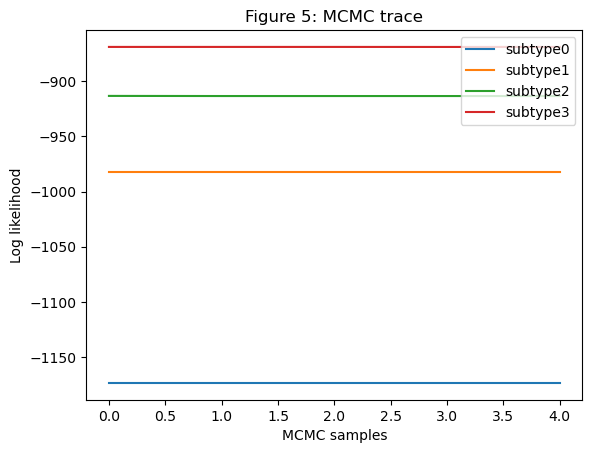

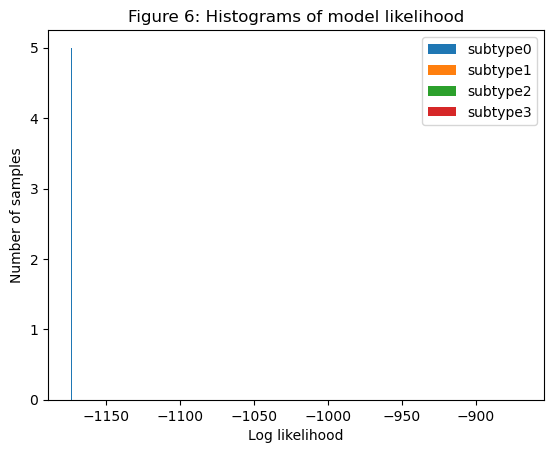

In [6]:
# check MCMC output
# go through each subtypes model and plot MCMC samples of the likelihood

for s in range(sustain_input.N_S_max):
    pickle_filename_s           = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pickle_filepath             = Path(pickle_filename_s)
    pickle_file                 = open(pickle_filename_s, 'rb')
    loaded_variables            = pickle.load(pickle_file)
    samples_likelihood          = loaded_variables["samples_likelihood"]
    pickle_file.close()

    _ = plt.figure(0)
    _ = plt.plot(range(sustain_input.N_iterations_MCMC), samples_likelihood, label="subtype" + str(s))
    _ = plt.figure(1)
    _ = plt.hist(samples_likelihood, label="subtype" + str(s))
    
_ = plt.figure(0)
_ = plt.legend(loc='upper right')
_ = plt.xlabel('MCMC samples')
_ = plt.ylabel('Log likelihood')
_ = plt.title('Figure 5: MCMC trace')
    
_ = plt.figure(1)
_ = plt.legend(loc='upper right')
_ = plt.xlabel('Log likelihood')  
_ = plt.ylabel('Number of samples')  
_ = plt.title('Figure 6: Histograms of model likelihood')

In [7]:
#/////stratified cross validation//////
# identify a control population

#we assume we know some ground truth 'gt' for the stages that the training data is at
# simulate subtypes and stages for individuals, including a control population at stage 0

# ground truth proportion of individuals belonging to each subtype 
N_k                     = np.sum(n_scores>0)+1
M = n_subjects 
N_S_gt = 2
M_control               = 20       # number of these that are control subjects 20 of 100
gt_f                    = [1+0.5*x for x in range(N_S_gt)]
gt_f                    = [x/sum(gt_f) for x in gt_f][::-1]
gt_subtypes             = np.random.choice(range(2), M, replace=True, p=gt_f)
gt_stages_control       = np.zeros((M_control,1))
gt_stages               = np.concatenate((gt_stages_control,
                                         np.ceil(np.random.rand(M-M_control,1)*N_k)),
                                        axis=0)

data = X #redefine here

index_control           = np.reshape(gt_stages,(M))==0

# label cases and controls to perform stratified cross-validation
labels                  = 1 * np.ones(data.shape[0], dtype=int) 
labels[index_control]   = 0

# choose the number of folds - here i've used three for speed but i recommend 10 typically
N_folds                  = 3

# generate stratified cross-validation training and test set splits
cv                       = sklearn.model_selection.StratifiedKFold(n_splits=N_folds, 
                                                                   shuffle=True)
cv_it                    = cv.split(data, labels)


test_idxs = []
for train, test in cv_it:
    test_idxs.append(test)
#just keep test_idx as a list no nparray for now since theyre different column lengths :///



In [8]:
# run the Cross validation now

# perform cross-validation and output the cross-validation information criterion and
# log-likelihood on the test set for each subtypes model and fold combination
CVIC, loglike_matrix     = sustain_input.cross_validate_sustain_model(test_idxs)

Folds:   0%|          | 0/3 [00:00<?, ?it/s]

Loading ./sustain_output/pickle_files/simulated_Data_fold0_subtype0.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold0_subtype1.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold0_subtype2.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold0_subtype3.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold1_subtype0.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold1_subtype1.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold1_subtype2.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold1_subtype3.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold2_subtype0.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold2_subtype1.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold2_subtype2.pickle
Loading ./sustain_output/pickle_files/simulated_Data_fold2_subtype3.pickle
Average test set log-likelihood for each subtype model: [-394.97925831 -339.01904305 -336.44661866 -

CVIC for each subtype model: [2490.03315485 2183.81596867 2018.55146836 1929.25721676]
Average test set log-likelihood for each subtype model: [-394.97925831 -339.01904305 -336.44661866 -322.05796364]
The subtype model with the highest LL and lowest CVIC is the best


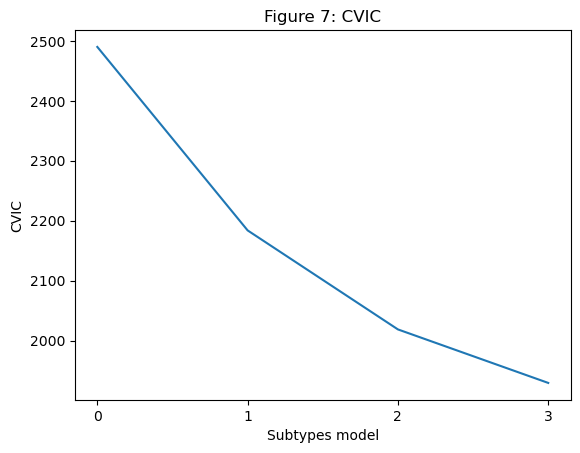

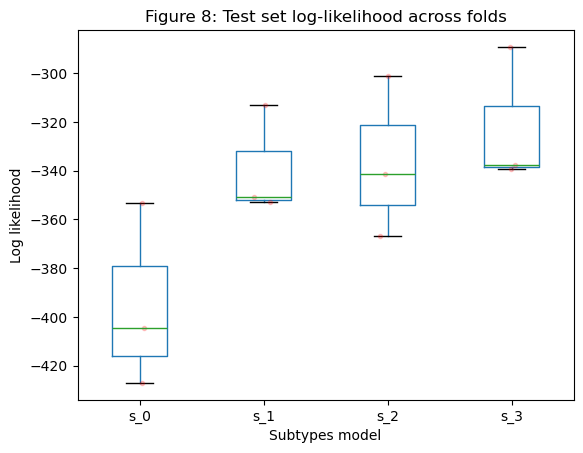

In [9]:
#plotting adpated from the zscore model:: # go through each subtypes model and plot the log-likelihood on the test set and the CVIC
N_S_max = sustain_input.N_S_max
print("CVIC for each subtype model: " + str(CVIC))
print("Average test set log-likelihood for each subtype model: " + str(np.mean(loglike_matrix, 0)))

_ = plt.figure(1)    
_ = plt.plot(np.arange(N_S_max,dtype=int),CVIC)
_ = plt.xticks(np.arange(N_S_max,dtype=int))
_ = plt.ylabel('CVIC')  
_ = plt.xlabel('Subtypes model') 
_ = plt.title('Figure 7: CVIC')

_ = plt.figure(0)
df_loglike                                 = pd.DataFrame(data = loglike_matrix, columns = ["s_" + str(i) for i in range(sustain_input.N_S_max)])
df_loglike.boxplot(grid=False)
for i in range(sustain_input.N_S_max):
    y                                   = df_loglike[["s_" + str(i)]]
    x                                   = np.random.normal(1+i, 0.04, size=len(y)) # Add some random "jitter" to the x-axis
    pylab.plot(x, y, 'r.', alpha=0.2)
_ = plt.ylabel('Log likelihood')  
_ = plt.xlabel('Subtypes model') 
_ = plt.title('Figure 8: Test set log-likelihood across folds')

print('The subtype model with the highest LL and lowest CVIC is the best')


In [10]:
#this part estimates cross-validated positional variance diagrams
print(N_S_max)

#debugging
print(f"N_biomarkers = {n_biomarkers}, N_z = {n_scores}")
print(f"Expected max biomarker index = {n_biomarkers - 1}")
print("----")
#define N_biomarkers

for i in range(N_S_max):
    sustain_input.combine_cross_validated_sequences(i+1, N_folds)


4
N_biomarkers = 3, N_z = 4
Expected max biomarker index = 2
----


IndexError: index 9 is out of bounds for axis 0 with size 9

In [ ]:
import pickle
import numpy as np
import os

# Parameters
n_biomarkers = 3
N_S_max = 1
N_folds = 3
output_folder = "./sustain_output/pickle_files"

# Inspect CV sequence files
for subtype in range(1, N_S_max + 1):
    print(f"\nChecking subtype count: {subtype}")
    for fold in range(N_folds):
        filename = f"{output_folder}/{dataset_name}_fold{fold}_subtype{subtype}.pickle"
        if not os.path.exists(filename):
            print(f"  ❌ Missing file: {filename}")
            continue

        with open(filename, 'rb') as f:
            loaded = pickle.load(f)

        seq = loaded.get("samples_sequence", None)
        if seq is None:
            print(f"  ❌ 'samples_sequence' not found in fold {fold}")
            continue

        seq = np.array(seq)
        print(f"  Fold {fold}: shape = {seq.shape}")
        print(f"    Min index = {np.min(seq)}, Max index = {np.max(seq)}")
        if np.max(seq) >= n_biomarkers:
            print(f"  🚨 Invalid index in fold {fold}: max {np.max(seq)} >= {n_biomarkers}")


In [ ]:
#show the predicted squences
print("Inferred event sequence:", model.S_)